<div style="background:#d4edda; border-left:6px solid #155724; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#155724;">
<h2 style="margin:0;">Read Me</h2>
<p style="margin:8px 0 0 0; font-size:14px;">
Welcome to your first lab assignment! These assignments are designed to reinforce the content covered in class, in a new context. They are also meant to show you what it looks like to implement these topics in code and help prepare you for the exam. A few notes:
<ol style="margin:8px 0 0 0; font-size:14px; padding-left:20px;">
<li>This assignment is graded on completion. For credit, you must provide a reasonable answer to every question.</li>
<li>As you scroll through this notebook, <strong>blue boxes</strong> indicate the questions you need to answer. Your answer may need to be a written response, code, or both. The blocks below the question will prompt you for your answer.</li>
<li>When you write your non-code answers, you can use <code>#</code> to start a comment inside a code cell. Alternatively, you can change the block to a Markdown cell using the dropdown at the top — this will allow you to write freely without <code>#</code>.</li>
<li>Format your notebook so it can run from top to bottom without issues. In other words, the double-arrow &#9654;&#9654; button should work without error.</li>
<li>When you submit, please submit a PDF of this file. Use the answer selection tool in Gradescope so our TA team can easily find your answers.</li>
</ol>
Thanks!
</p>
</div>

## Scenario

**Human Immunodeficiency Virus (HIV)** is a type of retrovirus that attacks the immune system. The virus specifically attacks CD4 cells, a type of white blood cell. If a person's CD4 count falls below 200 cells per cubic millimeter, they are then classified as having **Acquired Immunodeficiency Syndrome (AIDS)**. Without treatment, half of those living with HIV will develop AIDS within 10 years.

In this lab, you will analyze data from one of the most famous clinical trials conducted in search of a treatment for HIV. In this study, several thousand HIV-positive patients were randomly assigned to one of four treatment groups being evaluated in the 1990s:

<ol style="margin:8px 0 0 0; font-size:14px; padding-left:40px;">
<li>Zidovudine only &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>(Treatment Group 0)</strong></li>
<li>Zidovudine + Didanosine &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>(Treatment Group 1)</strong></li>
<li>Zidovudine + Zalcitabine &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>(Treatment Group 2)</strong></li>
<li>Didanosine only &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>(Treatment Group 3)</strong></li>
</ol>

We will refer to them simply as treatment groups 0–3. The goal of our analysis is to determine what factors are associated with slowing the decline in CD4 cells in HIV-positive patients. The columns in the dataset are as follows:

| Column | Description |
|---|---|
| `trt` | Treatment group (0, 1, 2, or 3) |
| `age` | Age at baseline (years) |
| `wtkg` | Weight at baseline (kg) |
| `hemo` | Hemophiliac (1 = yes, 0 = no), disorder that impairs the body's ability to make blood clots |
| `homo` | Reports homosexual activity (1 = yes, 0 = no) |
| `drugs` | History of IV drug use (1 = yes, 0 = no) |
| `oprior` | Non-zidovudine antiretroviral therapy prior to study (1 = yes, 0 = no) |
| `z30` | Zidovudine use in the 30 days prior to study entry (1 = yes, 0 = no) |
| `preanti` | Days of prior antiretroviral therapy |
| `str2` | Antiretroviral history (0 = naive, 1 = experienced) |
| `race` | Race (0 = white, 1 = non-white) |
| `gender` | Gender (0 = female, 1 = male) |
| `symptom` | Symptomatic at baseline (1 = yes, 0 = no) |
| `cd40` | CD4 count at baseline (cells/mm³) |
| `cd420` | CD4 count at 20 weeks (cells/mm³) |

<div style="background:#f8d7da; border-left:6px solid #721c24; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#721c24;">
<h2 style="margin:0;">Part 1: Understand the Data and EDA</h2>

</div>

In [37]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import scikit_posthocs as sp
import math



pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [38]:
# Load data
df = pd.read_csv('data.csv')
display(df.head())
print(f"Shape: {df.shape}")
print("\nData types:\n", df.dtypes)

,trt,age,wtkg,hemo,homo,drugs,oprior,z30,preanti,race,gender,str2,symptom,cd40,cd420
0,2,48,89.8128,0,0,0,0,0,0,0,0,0,0,422,477
1,3,61,49.4424,0,0,0,0,1,895,0,0,1,0,162,218
2,3,45,88.4520,0,1,1,0,1,707,0,1,1,0,326,274
3,3,47,85.2768,0,1,0,0,1,1399,0,1,1,0,287,394
4,0,43,66.6792,0,1,0,0,1,1352,0,1,1,0,504,353


Shape: (2139, 15)

Data types:
 trt          int64
age          int64
wtkg       float64
hemo         int64
homo         int64
drugs        int64
oprior       int64
z30          int64
preanti      int64
race         int64
gender       int64
str2         int64
symptom      int64
cd40         int64
cd420        int64
dtype: object


<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 1: Bias Check</h2>
<p style="margin:8px 0 0 0; font-size:14px;">Before we do anything with this data, we should always understand how the data was collected.
The trial reports the following recruitment criteria:
<br><br>
<em>"We recruited patients from 43 AIDS Clinical Trials Units and 9 National Hemophilia Foundation
sites in the United States and Puerto Rico who met the following eligibility criteria: age of 12 years
or more, laboratory documentation of HIV-1 infection, a CD4 cell count between 200 and 500 per cubic
millimeter within 30 days before randomization, no history of an AIDS-defining illness, and acceptable
laboratory results. [...] Patients were randomly assigned to one of four treatments. A blocked
randomization design, carried out with a central computerized system, was used at each study site and
was stratified according to the length of prior antiretroviral therapy."</em>
<br><br>
Based on this description, the patient demographics in the data, and what you know about HIV/AIDS,
do you believe the data is biased? If so, what type of bias (from the categories covered in class) applies?</p>
</div>

In [39]:
# Written Answer Here:
# The data is biased. Sampling bias, for the sample only includes patients from several hospitals in US and Puerto Rico. We can't generalize this to all patients from the world or even from different races. Survivor bias and measurement bias, the patients should have a CD4 cell count between 200 and 500 per cubic millimeter within 30 days before randomization, no history of an AIDS-defining illness, which means their health condition are not that severe.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 2: Correlation Check</h2>
<p style="margin:8px 0 0 0; font-size:14px;">Before modeling, we check for correlation between columns.
Features that move together have a positive correlation (close to +1);
those that move in opposite directions have a negative correlation (close to −1).
Highly correlated input features can cause problems for our models later on — keep an eye on any strong pairs.</p>
</div>

In [40]:
display(df.corr(numeric_only=True).style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1))
corrVar = df.corr(numeric_only=True)
corrPair = corrVar.unstack()
corrPair = corrPair[corrPair!=1].drop_duplicates().abs().sort_values(ascending=False)
print(corrPair.head(5))

,trt,age,wtkg,hemo,homo,drugs,oprior,z30,preanti,race,gender,str2,symptom,cd40,cd420
trt,1.000000,-0.001931,-0.031685,0.012329,0.025035,0.005712,-0.026805,-0.001656,0.006710,0.017080,0.022691,-0.003003,-0.000765,-0.012770,0.064448
age,-0.001931,1.000000,0.132858,-0.231257,0.158917,0.077446,0.056161,0.061178,0.113220,-0.097678,0.048705,0.068230,0.032814,-0.040302,-0.044294
wtkg,-0.031685,0.132858,1.000000,-0.075791,0.155909,0.002343,0.009607,-0.073841,-0.079292,-0.081452,0.240013,-0.078885,0.003942,0.036401,0.020980
hemo,0.012329,-0.231257,-0.075791,1.000000,-0.391307,-0.092957,0.034978,0.111554,0.113892,-0.070333,0.115867,0.124983,-0.076296,-0.022533,-0.065838
homo,0.025035,0.158917,0.155909,-0.391307,1.000000,-0.206876,0.019743,-0.049760,0.014132,-0.307108,0.607820,-0.036700,0.118575,0.000511,0.019915
drugs,0.005712,0.077446,0.002343,-0.092957,-0.206876,1.000000,-0.029968,0.014961,-0.029981,0.082311,-0.141748,0.001106,0.027052,-0.003360,0.013109
oprior,-0.026805,0.056161,0.009607,0.034978,0.019743,-0.029968,1.000000,-0.037580,0.067082,-0.003923,0.042976,0.126040,0.024199,-0.059199,-0.109643
z30,-0.001656,0.061178,-0.073841,0.111554,-0.049760,0.014961,-0.037580,1.000000,0.655054,-0.073658,-0.036119,0.903417,0.020883,-0.121282,-0.200149
preanti,0.006710,0.113220,-0.079292,0.113892,0.014132,-0.029981,0.067082,0.655054,1.000000,-0.124939,0.032099,0.680354,0.012304,-0.067495,-0.132213
race,0.017080,-0.097678,-0.081452,-0.070333,-0.307108,0.082311,-0.003923,-0.073658,-0.124939,1.000000,-0.292146,-0.080510,-0.078378,-0.001290,-0.035935


z30      str2      0.9034
preanti  str2      0.6804
z30      preanti   0.6551
homo     gender    0.6078
cd40     cd420     0.5836
dtype: float64


In [41]:
# Written Answer Here: 
# What pairs of features have the highest correlation (list the top 5)? Does this make sense intuitively?
# Answer: For simplicity, I personally add some code to find the top 5 highest correlation pairs, they are: (z30,str2),(preanti, str2),(z30,preanti),(homo,gender),(cd40,cd420). (z30,str2) make sense for patient uses Zidovudine in the 30 days vs patient has antiretroviral history. (preanti, str2) make sense for patient has prior antiretroviral therapy vs patient has antiretroviral history. (z30,preanti) make sense for patient has prior antiretroviral therapy vs patient uses Zidovudine in the 30 days.(homo,gender) make sense for gender=1 indicates male and homo=1 indicates homosexual activity. (cd40,cd420) make sense for a patient whose CD4 count at baseline is high, that patient's CD4 count at 20 weeks may also be high


<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 3: Outlier Check</h2>
<p style="margin:8px 0 0 0; font-size:14px;">The box-and-whisker plots below show the distribution of every feature. Outliers appear as points beyond the whiskers.</p>
</div>

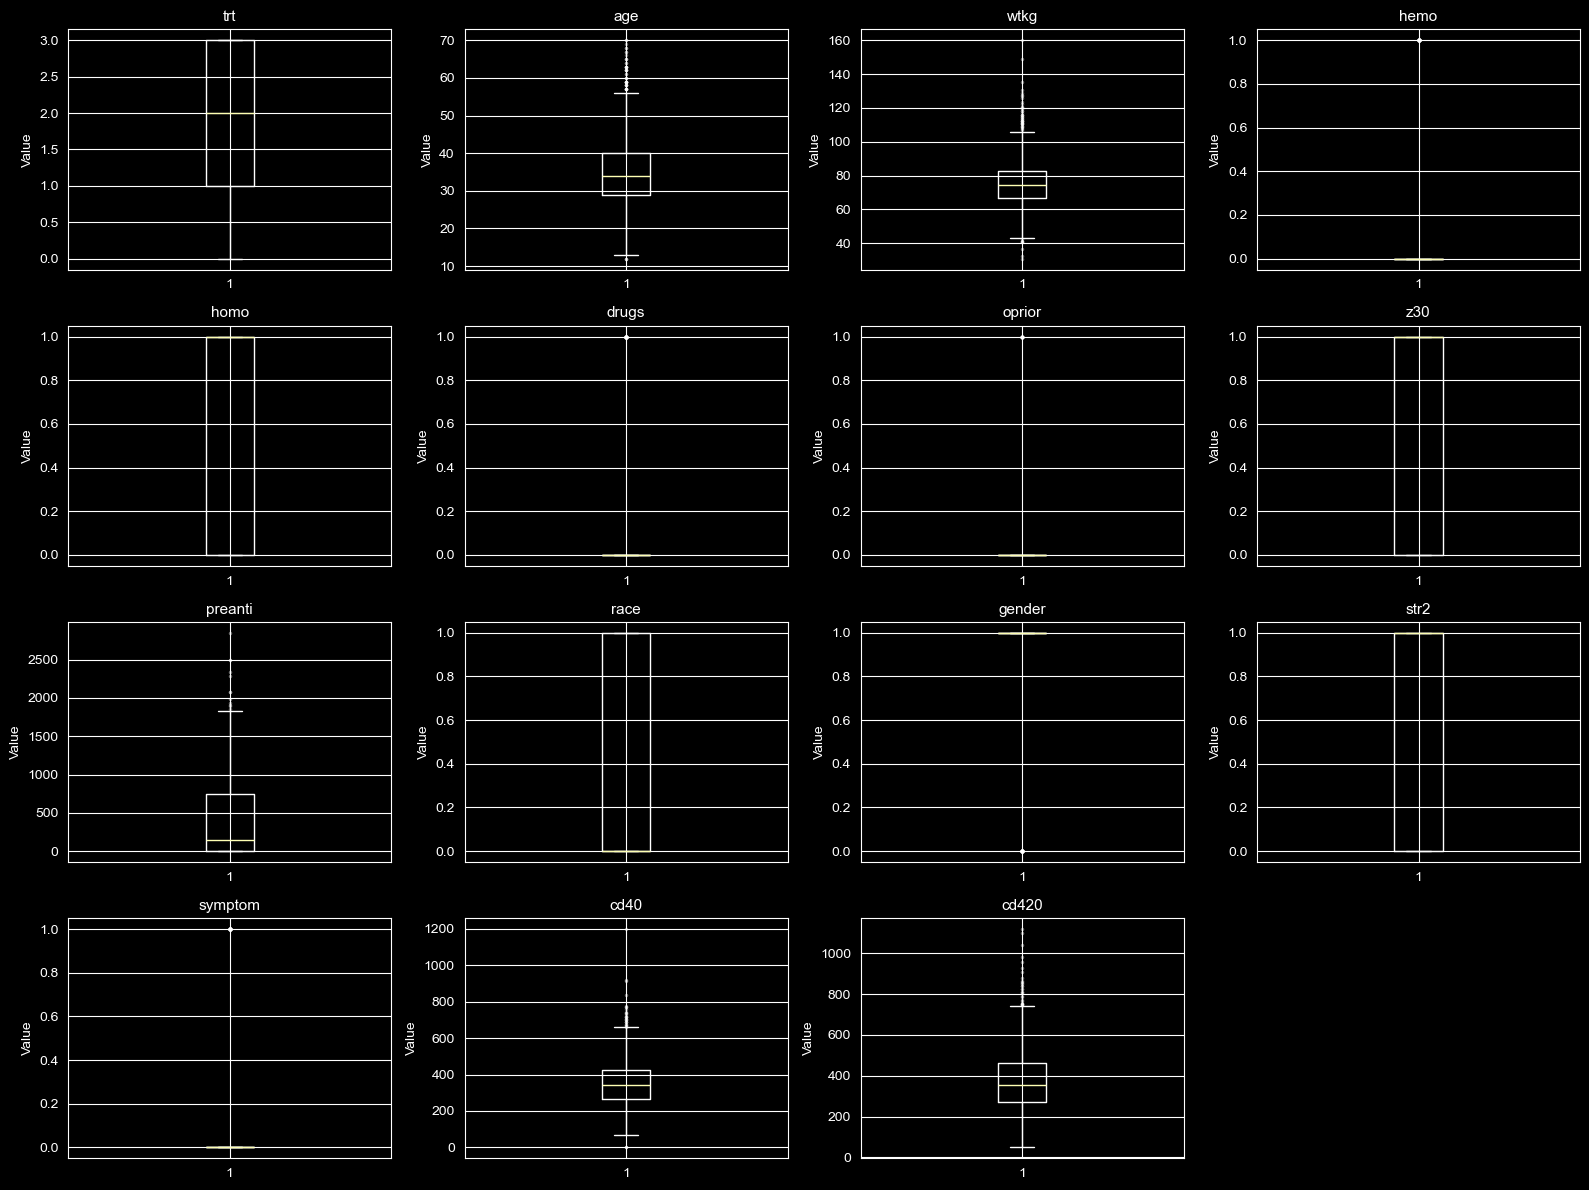

In [42]:
numeric_cols = df.select_dtypes(include='number').columns
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), flierprops=dict(marker='.', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [43]:
# Written Answer Here: 
# Do any of the outliers look like data-entry errors, or are they plausible extreme values? Explain.
# Answer: Outliers in age is plausible, for people can be above 55. Outliers in wtkg might be data-entry errors, for people could not be 160kg. hemo\drugs\oprior\preanti/symptom is plausible for it. gender is plausible for woman patient. cd40 may be errors for the sampling criteria that CD4 cell count between 200 and 500. cd420 may be plausible for no such restriction.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 4: EDA — Histograms</h2>
<p style="margin:8px 0 0 0; font-size:14px;">The goal of the trial was to increase patients' CD4 cell count.
Let's create a <strong>change</strong> feature (CD4 at week 20 minus CD4 at baseline) and use it to understand:
<ol style="margin:8px 0 0 0; font-size:14px; padding-left:20px;">
<li>How much did patients improve overall?</li>
<li>Does gender impact improvement? (code provided)</li>
<li>Does prior antiretroviral history (<code>str2</code>) impact improvement? (you write the code)</li>
</ol></p>
</div>

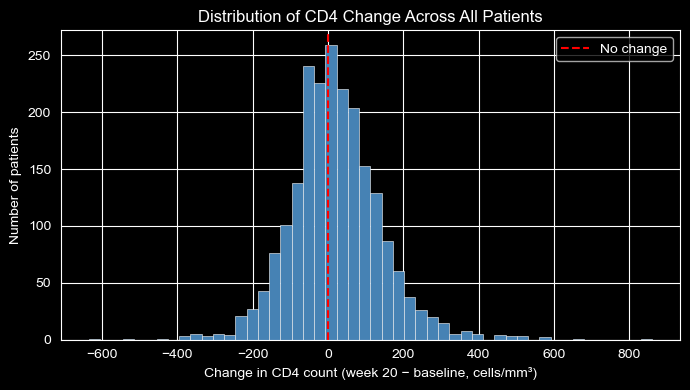

Mean change: 20.8
Patients who improved: 55.0%


In [44]:
df['change'] = df['cd420'] - df['cd40']

plt.figure(figsize=(7, 4))
plt.hist(df['change'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
plt.axvline(0, color='red', linestyle='--', label='No change')
plt.xlabel('Change in CD4 count (week 20 − baseline, cells/mm³)')
plt.ylabel('Number of patients')
plt.title('Distribution of CD4 Change Across All Patients')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean change: {df['change'].mean():.1f}")
print(f"Patients who improved: {(df['change'] > 0).mean() * 100:.1f}%")

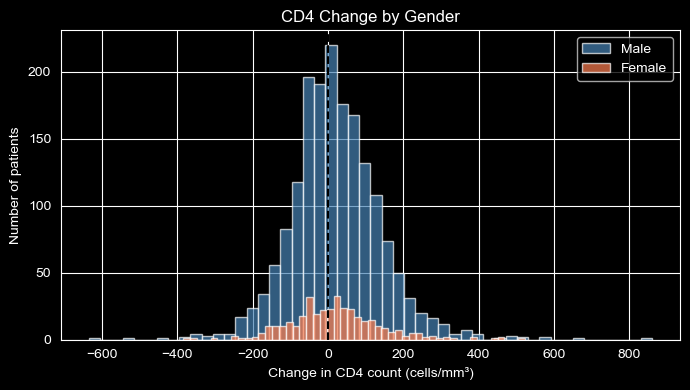

Male   — Mean:    20.9  Std: 121.9    % improved: 55.0%
Female — Mean:    20.3  Std: 124.6    % improved: 54.9%


In [45]:
# Gender comparison (provided)
plt.figure(figsize=(7, 4))
plt.hist(df[df.gender == 1]['change'], bins=50, label='Male', alpha=0.7, color='steelblue')
plt.hist(df[df.gender == 0]['change'], bins=50, label='Female', alpha=0.7, color='coral')
plt.axvline(0, color='black', linestyle='--')
plt.legend()
plt.xlabel('Change in CD4 count (cells/mm³)')
plt.ylabel('Number of patients')
plt.title('CD4 Change by Gender')
plt.tight_layout()
plt.show()

for label, val in [(1, 'Male'), (0, 'Female')]:
    grp = df[df.gender == label]['change']
    print(f"{val:6s} — Mean: {grp.mean():7.1f}  Std: {grp.std():.1f}  "
          f"  % improved: {(grp > 0).mean() * 100:.1f}%")

In [46]:
# Written Answer Here: 
# Does a patient's gender seem to impact their outcome in this trial? Explain.
# Answer: patient's gender seem not impacting. However, the number for female samples is limited, so this might lead to some bias.

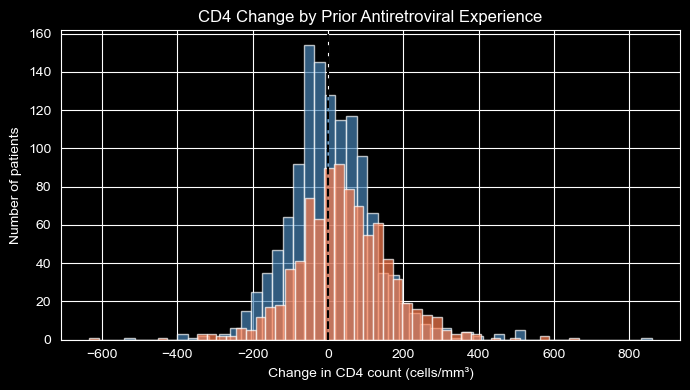

With str2     — Mean:     6.9  Std: 117.8    % improved: 49.1%
Without str2  — Mean:    40.5  Std: 125.9    % improved: 63.3%


In [47]:
# Code Here: 
# Create a layered histogram showing patients with prior antiretroviral experience (str2)
# Hint: use the same structure as the gender plot above
plt.figure(figsize=(7,4))
plt.subplot(1,1,1)
plt.hist(df[df['str2']==1]['change'], bins=50, label='with str2',color='steelblue',alpha=0.7)
plt.hist(df[df['str2']==0]['change'], bins=50, label='without str2',color='coral',alpha=0.7)
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Change in CD4 count (cells/mm³)')
plt.ylabel('Number of patients')
plt.title('CD4 Change by Prior Antiretroviral Experience')
plt.tight_layout()
plt.show()

for label, val in [(1, 'With str2'), (0, 'Without str2')]:
    grp = df[df.str2 == label]['change']
    print(f"{val:13s} — Mean: {grp.mean():7.1f}  Std: {grp.std():.1f}  "
          f"  % improved: {(grp > 0).mean() * 100:.1f}%")


In [48]:
# Written Answer Here: 
# Does prior antiretroviral experience (str2) appear to matter? Explain.
# It matters, comparing to patient With str2 has Mean:6.9, patients without str2 whose Mean:40.5 improve significantly

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 5: Baseline CD4 and Treatment Response</h2>
<p style="margin:8px 0 0 0; font-size:14px;">The scatter plot below shows each patient's baseline CD4 count versus their change over 20 weeks.</p>
</div>

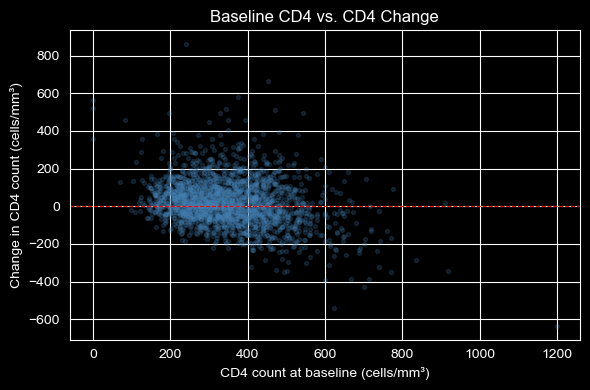

In [49]:
plt.figure(figsize=(6, 4))
plt.scatter(df['cd40'], df['change'], alpha=0.2, s=8, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('CD4 count at baseline (cells/mm³)')
plt.ylabel('Change in CD4 count (cells/mm³)')
plt.title('Baseline CD4 vs. CD4 Change')
plt.tight_layout()
plt.show()

In [50]:
# Written Answer Here: 
# Does a patient's baseline CD4 count appear to be related to how much they improve? What direction is the relationship and why might that be?
# Answer: Patients with baseline CD4 levels 200–500 cells/mm³ show the widest range of changes, with both substantial increases and decreases in CD4 count. Most data points in this interval, form an elliptical distribution. However, patients whose baseline is  below 200 experience negative changes and are all positive, and patients whose baseline CD4 count is above 600 almost exclusively experience negative changes, but both of their quantity is relatively small. Perhaps the higher(higher than certain threshold like 600) a patient’s initial baseline CD4 value, the less likely they are to gain CD4 cells, and they are more prone to CD4 decline.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 6: Treatment Group Comparison</h2>
<p style="margin:8px 0 0 0; font-size:14px;">Let's compare how the four treatment groups performed using box-and-whisker plots.</p>
</div>

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6508\4230121174.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1, data2, data3], labels=['Trt 0\n(ZDV)', 'Trt 1\n(ZDV+ddI)', 'Trt 2\n(ZDV+ddC)', 'Trt 3\n(ddI)'],


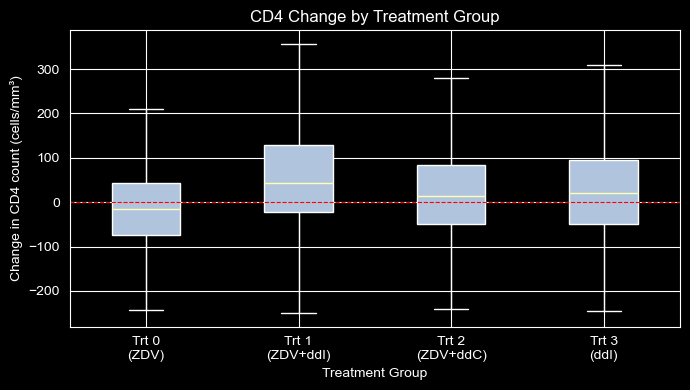

Trt 0 — Mean:   -17.1  Std: 104.7  % improved: 43.6%
Trt 1 — Mean:    54.4  Std: 144.3  % improved: 65.3%
Trt 2 — Mean:    19.3  Std: 112.4  % improved: 55.5%
Trt 3 — Mean:    26.9  Std: 114.5  % improved: 55.6%


In [51]:
data0 = df[df.trt == 0]['change']
data1 = df[df.trt == 1]['change']
data2 = df[df.trt == 2]['change']
data3 = df[df.trt == 3]['change']

plt.figure(figsize=(7, 4))
plt.boxplot([data0, data1, data2, data3], labels=['Trt 0\n(ZDV)', 'Trt 1\n(ZDV+ddI)', 'Trt 2\n(ZDV+ddC)', 'Trt 3\n(ddI)'],
            showfliers=False, patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue'))
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Treatment Group')
plt.ylabel('Change in CD4 count (cells/mm³)')
plt.title('CD4 Change by Treatment Group')
plt.tight_layout()
plt.show()

for label, grp in zip(['Trt 0', 'Trt 1', 'Trt 2', 'Trt 3'], [data0, data1, data2, data3]):
    print(f"{label} — Mean: {grp.mean():7.1f}  Std: {grp.std():.1f}  % improved: {(grp > 0).mean() * 100:.1f}%")

In [52]:
# Written Answer Here: 
# Based on the plot and the summary statistics, which treatment group(s) appear most effective?
# Treatment1 (ZDV+ddI). It achieves the highest average CD4 gain, highest median change, and the majority of its patients have positive gain, but it also has the greatest variability in patients.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 7: Two More Figures of Your Choice</h2>
<p style="margin:8px 0 0 0; font-size:14px;">Create two additional EDA figures that reveal something interesting about the data. Interpret each one. I encourage you to use AI.</p>
</div>

In [53]:
# Code Here: 
# Figure 1


In [54]:
# Written Answer Here: 
# Key insight from Figure 1

In [55]:
# Code Here: 
# Figure 2


In [56]:
# Written Answer Here: 
# Key insight from Figure 2

<div style="background:#f8d7da; border-left:6px solid #721c24; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#721c24;">
<h2 style="margin:0;">Part 2: Hypothesis Testing</h2>

</div>

Each hypothesis below follows the same structure you learned in class:
1. Define a random variable and state H₀ and H₁
2. Determine the distribution if H₀ is true and compute the p-value
3. Interpret the result at the α = 0.05 significance level

The three hypotheses are scaffolded differently, by the third one, you are doing it entirely on your own.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 1: Do More Than Half of Treatment Group 2 Patients Improve?</h2>
<p style="margin:8px 0 0 0; font-size:14px;">Let <strong>X</strong> be a Bernoulli random variable equal to 1 if a patient in treatment group 2
has a higher CD4 count at week 20 than at baseline (i.e., <em>change &gt; 0</em>), and 0 otherwise.
<br><br>
<strong>H₀:</strong> E[X] ≤ 0.5 &nbsp;&nbsp; (at most half of patients improve)<br>
<strong>H₁:</strong> E[X] &gt; 0.5 &nbsp;&nbsp; (more than half of patients improve)
<br><br>
The code below runs the appropriate test. Your job is to interpret the result.</p>
</div>

In [57]:
# Hypothesis 1 — one-proportion z-test (code provided)

# First, compute what we observed
trt2     = df[df['trt'] == 2]
improved = (trt2['change'] > 0).sum()
n        = len(trt2)
p_hat    = improved / n

print(f"In our data, {improved} of {n} patients in treatment group 2 improved ({p_hat * 100:.1f}%)")
print(f"Notice, our data is already above 0.5 — but is it enough to statistically reject H0?")
print()

# Let X = 1 if a patient improved, 0 otherwise.
# Y = (1/n) * sum(X_i) is the sample proportion — the average of n independent draws of X.
# Under H0 at the most extreme, E[X] = 0.5, so by the CLT:
#   Y ~ Normal(mean=0.5, variance=0.5*(1-0.5)/n)
var = 0.5 * (1 - 0.5) / n

print(f"Under H0: Y ~ Normal(mean=0.5, variance={var:.6f})")
print(f"We observed Y = {p_hat:.3f}")
print(f"p-value = P(Y >= {p_hat:.3f}) under H0")
print()

p_value = 1 - stats.norm.cdf(p_hat, loc=0.5, scale=np.sqrt(var))
print(f"p-value: {p_value:.4f}")

In our data, 291 of 524 patients in treatment group 2 improved (55.5%)
Notice, our data is already above 0.5 — but is it enough to statistically reject H0?

Under H0: Y ~ Normal(mean=0.5, variance=0.000477)
We observed Y = 0.555
p-value = P(Y >= 0.555) under H0

p-value: 0.0056


In [58]:
# Written Answer Here: 
# 1. In words, what does the p-value represent in this context?
# Answer: p-value means that assuming less than 50% patients improve,the probability of  observing 55.5% or above patients improve is at least as extreme as 0.0056.
# 2. At α = 0.05, do we reject H₀? What does that mean for Treatment Group 2?
# Answer: We reject H0,for 0.0056<0.05, which means Treatment 2 have more than half of the patient have positive change.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 2: Did Treatment Group 0 Have Any Effect on CD4 Count?</h2>
<p style="margin:8px 0 0 0; font-size:14px;">Let <strong>X</strong> be a random variable equal to the change in CD4 count for a patient in treatment group 0.
<br><br>
<strong>H₀:</strong> E[X] = 0 &nbsp;&nbsp; (treatment group 0 has no effect on average CD4 count)<br>
<strong>H₁:</strong> E[X] ≠ 0 &nbsp;&nbsp; (treatment group 0 does have some effect)
<br><br>
We have already isolated the data for you below. Your job is to:
<ol style="margin:8px 0 0 0; font-size:14px; padding-left:20px;">
<li>Look up the appropriate statistical test for this type of hypothesis (hint: we are testing a sample mean against a known value).</li>
<li>Run the test using <code>scipy.stats</code>.</li>
<li>Report and interpret the p-value.</li>
</ol></p>
</div>

In [59]:
# Hypothesis 2 — find and run the appropriate test (you write the code)

# Let X = change in CD4 count for a patient in treatment group 0.
# Y = (1/n) * sum(X_i) is the sample mean — the average of n independent draws of X.
# We want to test whether E[X] = 0.
trt0 = df[df['trt'] == 0]['change']

n    = len(trt0)
ybar = trt0.mean()
print(f"n    = {n}")
print(f"Y    = {ybar:.2f} cells/mm³")
print()

# In Hypothesis 1, X was Bernoulli so we knew the variance was p*(1-p).
# Here, X is continuous with no closed-form variance — we have to estimate it from the data.
var_hat = trt0.var(ddof=1)
print(f"Estimated variance of X = {var_hat:.2f}")
print()

# With n >> 30, the CLT kicks in strongly and we are comfortable treating Y as Normal.
# Under H0: Y ~ Normal(mean=0, variance=var_hat/n)
var_y = var_hat / n
print(f"Under H0: Y ~ Normal(mean=0, variance={var_y:.4f})")
print(f"We observed Y = {ybar:.2f}")
print()

# H1 is two-sided (E[X] != 0), so we reject if Y is too far from 0 in either direction.
# Hint: compute the one-sided p-value P(Y <= ybar) and double it.
print(f"p-value = 2 * P(Y <= {ybar:.2f}) under H0")
print()


n    = 532
Y    = -17.07 cells/mm³

Estimated variance of X = 10961.09

Under H0: Y ~ Normal(mean=0, variance=20.6036)
We observed Y = -17.07

p-value = 2 * P(Y <= -17.07) under H0



In [60]:
# Code Here: 
# Run the appropriate test and print the p-value
p_value = 2 * stats.norm.cdf(ybar,loc=0, scale=np.sqrt(var_y))
print(f"p-value: {p_value:.4f}")

p-value: 0.0002


In [61]:
# Written Answer Here: 
# 1. What test did you use, and why is it appropriate here?
# Answer: CLT's normal test, for n=532>30, CLT holds.
# 2. What is the p-value?
# Answer: p-value: 0.0002
# 3. Do we reject H₀ at α = 0.05? What does this say about Treatment Group 0?
# Answer: We reject, means Treantment 0 have effect on avg CD4 count

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 3: Do Treatment Groups 1 and 2 Achieve Equal Rates of Staying Above 200 cells/mm³?</h2>
<p style="margin:8px 0 0 0; font-size:14px;">A CD4 count above 200 cells/mm³ is the clinical threshold that separates HIV from AIDS.
Let's test whether the two combination therapies (Groups 1 and 2) result in the same proportion of patients
staying above this threshold at week 20.
<br><br>
Let <strong>X₁</strong> = 1 if a patient in treatment group 1 has <em>cd420 &gt; 200</em>, 0 otherwise.<br>
Let <strong>X₂</strong> = 1 if a patient in treatment group 2 has <em>cd420 &gt; 200</em>, 0 otherwise.
<br><br>
<strong>H₀:</strong> E[X₁] = E[X₂]<br>
<strong>H₁:</strong> E[X₁] ≠ E[X₂]
<br><br>
<strong>This one is on you.</strong> Figure out which distribution the test statistic follows under H₀,
look up the appropriate test in <code>scipy.stats</code>, run it, and interpret the result.
Briefly explain your reasoning for the choice of test. The example from class is a great place to start. </p>
</div>

In [62]:
# Code Here:
trt1     = df[df['trt'] == 1]
aboveTRT1 = (trt1['cd420'] > 200).sum()
n1        = len(trt1)
rate1 = aboveTRT1 / n1

trt2     = df[df['trt'] == 2]
aboveTRT2 = (trt2['cd420'] > 200).sum()
n2        = len(trt2)
rate2 = aboveTRT2 / n2

p_hat_pooled    = (aboveTRT1+aboveTRT2) / (n1+n2)

p_value = 2 * (1-stats.norm.cdf(abs(rate1-rate2), loc=0, scale=np.sqrt(p_hat_pooled*(1-p_hat_pooled)*(1/n1+1/n2))))
print(f"n1    = {n1}")
print(f"n2    = {n2}")
print(f"p-value: {p_value:.4f}")

n1    = 522
n2    = 524
p-value: 0.8920


In [63]:
# Written Answer Here: 
# 1. What distribution does the test statistic follow under H₀? Why?
# Answer: Normal, for linear combination of independent Normal is still Normal
# 2. What test did you use?
# Answer: CLT's Normal test
# 3. What is the p-value, and what is your conclusion at α = 0.05?
# Answer: p-value: 0.8920, we fail to reject H0, i.e., group 1 and 2 results in the same proportion

<div style="background:#f8d7da; border-left:6px solid #721c24; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#721c24;">
<h2 style="margin:0;">Part 3: Explanatory Linear Regression</h2>

</div>

Now we move from testing individual hypotheses to building a model that estimates the effect of **all
features simultaneously**. We will use **Ordinary Least Squares (OLS) linear regression** with
`change` — the improvement in CD4 count over 20 weeks, as our outcome variable.

The three steps below walk you through preparing the data, checking for feature relevance, and fitting the model.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 1: One-Hot Encode the Treatment Variable</h2>
<p style="margin:8px 0 0 0; font-size:14px;">The column <code>trt</code> takes values 0, 1, 2, and 3.
Even though these look like numbers, they are <strong>categories</strong> — there is no meaningful ordering
or magnitude to treatment group membership.
If we leave <code>trt</code> as a raw integer, the regression would assume Group 3 is "three times" Group 1, which is nonsense.
<br><br>
<strong>One-hot encoding</strong> solves this by creating a separate binary column for each group.
We drop one category (the reference group) to avoid perfect multicollinearity.
<br><br>
Use <code>pd.get_dummies()</code> to one-hot encode <code>trt</code>, then display the first few rows of the result.</p>
</div>

In [64]:
# One-hot encode 'trt', dropping trt_3 as the reference group.
# The coefficients on trt_0, trt_1, trt_2 will each be interpreted
# relative to treatment group 3 (didanosine only).
df = pd.get_dummies(df, columns=['trt'], dtype=int)
df = df.drop(['trt_3'], axis=1)
display(df.head())
print("Treatment columns:", [c for c in df.columns if 'trt' in c])

,age,wtkg,hemo,homo,drugs,oprior,z30,preanti,race,gender,str2,symptom,cd40,cd420,change,trt_0,trt_1,trt_2
0,48,89.8128,0,0,0,0,0,0,0,0,0,0,422,477,55,0,0,1
1,61,49.4424,0,0,0,0,1,895,0,0,1,0,162,218,56,0,0,0
2,45,88.4520,0,1,1,0,1,707,0,1,1,0,326,274,-52,0,0,0
3,47,85.2768,0,1,0,0,1,1399,0,1,1,0,287,394,107,0,0,0
4,43,66.6792,0,1,0,0,1,1352,0,1,1,0,504,353,-151,1,0,0


Treatment columns: ['trt_0', 'trt_1', 'trt_2']


In [65]:
# Written Answer Here: 
# Why do we drop one of the one-hot encoded columns? What happens if we don't?
# Answer: Drop the redundant columns, to make the whole sample XTX invertible

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 2: Check for Multicollinearity</h2>
<p style="margin:8px 0 0 0; font-size:14px;">
Before fitting the model, we check for multicollinearity. That is, whether any of our input features are highly correlated with <em>each other</em>. If two features move together, the regression cannot cleanly separate their individual effects, and the coefficients become unreliable.<br><br>
Look at the heatmap below. If any pair of features has a correlation above ~0.8 (or below ~-0.8), we should consider dropping one of them.<br><br>
Are there any features you would drop before fitting the model? Why?
</p>
</div>

In [66]:
feature_cols = [c for c in df.columns if c not in ['change', 'cd40', 'cd420']]
df[feature_cols ].corr(numeric_only=True).style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

,age,wtkg,hemo,homo,drugs,oprior,z30,preanti,race,gender,str2,symptom,trt_0,trt_1,trt_2
age,1.000000,0.132858,-0.231257,0.158917,0.077446,0.056161,0.061178,0.113220,-0.097678,0.048705,0.068230,0.032814,-0.001499,-0.001198,0.011975
wtkg,0.132858,1.000000,-0.075791,0.155909,0.002343,0.009607,-0.073841,-0.079292,-0.081452,0.240013,-0.078885,0.003942,0.040638,-0.010915,-0.017660
hemo,-0.231257,-0.075791,1.000000,-0.391307,-0.092957,0.034978,0.111554,0.113892,-0.070333,0.115867,0.124983,-0.076296,-0.010786,-0.003635,0.007458
homo,0.158917,0.155909,-0.391307,1.000000,-0.206876,0.019743,-0.049760,0.014132,-0.307108,0.607820,-0.036700,0.118575,-0.024407,0.002135,0.003689
drugs,0.077446,0.002343,-0.092957,-0.206876,1.000000,-0.029968,0.014961,-0.029981,0.082311,-0.141748,0.001106,0.027052,-0.022055,0.014258,0.023048
oprior,0.056161,0.009607,0.034978,0.019743,-0.029968,1.000000,-0.037580,0.067082,-0.003923,0.042976,0.126040,0.024199,0.031801,-0.018338,0.011021
z30,0.061178,-0.073841,0.111554,-0.049760,0.014961,-0.037580,1.000000,0.655054,-0.073658,-0.036119,0.903417,0.020883,-0.003776,0.001676,0.012380
preanti,0.113220,-0.079292,0.113892,0.014132,-0.029981,0.067082,0.655054,1.000000,-0.124939,0.032099,0.680354,0.012304,-0.005682,-0.000078,-0.000304
race,-0.097678,-0.081452,-0.070333,-0.307108,0.082311,-0.003923,-0.073658,-0.124939,1.000000,-0.292146,-0.080510,-0.078378,0.006071,-0.030205,-0.002757
gender,0.048705,0.240013,0.115867,0.607820,-0.141748,0.042976,-0.036119,0.032099,-0.292146,1.000000,-0.031258,0.064373,-0.024280,0.005210,0.003314


In [67]:
# Code Here: 
# Write code to drop the feature z30

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 3: Fit a Linear Regression Model</h2>
<p style="margin:8px 0 0 0; font-size:14px;">We now fit an OLS regression with <code>change</code> as the outcome and all patient features as predictors.
The code and output are provided. Your job is to interpret the results. 
</div>

In [68]:
feature_cols = [c for c in df.columns if c not in ['change', 'cd420']]

X = df[feature_cols]
y = df['change']

X_const = sm.add_constant(X)
model   = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 change   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     25.97
Date:                Tue, 19 May 2026   Prob (F-statistic):           4.13e-71
Time:                        23:12:44   Log-Likelihood:                -13125.
No. Observations:                2139   AIC:                         2.628e+04
Df Residuals:                    2122   BIC:                         2.638e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        197.8294     19.727     10.028      0.0

In [69]:
# Written Answer Here: 

# 1. Does our model show, with statistical confidence, that at least one feature
#    has a non-zero effect? Look at the F-statistic and its p-value in the summary.
#    What is the null hypothesis of the F-test?
#  Answer: Our model does show that at least one feature has a non-zero effect. Null of F is that the coefficient of all features are 0, or the feature has 0 effect

# 2. How much of the variance in CD4 change does the model explain? (R²)
#    Is that high or low? What might explain the remaining variation?
#  Answer: From R-squared, 0.164, which is low. It explains 16.4% of the total variance in CD4 count change.

# 3. Which features have a statistically significant effect on CD4 change (α = 0.05)?
#  Answer: Based on P>|t|, const\hemo\oprior\race\str2\symptom\cd40\trt_0\trt_1

# 4. Treatment group 3 (didanosine only) is the reference category.
#    Compare each of the three treatment dummies (trt_0, trt_1, trt_2) to group 3:
#    which treatments lead to more CD4 improvement? Which lead to less?
#    Which differences are not statistically clear?
# Answer: Based on coef, trt_1 leads most improvement, trt_0 leads least improvement, trt_2 not so clear

# 5. Interpret the coefficient on cd40 (baseline CD4 count).
#    What does it mean practically?
#    Is it better to start the trial with a higher or lower CD4 count?
# Answer: It means that one unit increase in baseline CD4 count leads to an average decrease of 0.3226 units in CD4 change. It is better to begin the trial with a lower CD4 count.

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Question 4: Regression Assumptions Diagnostics</h2>
<p style="margin:8px 0 0 0; font-size:14px;">Every OLS model rests on four key assumptions. The plots below help you check each one.
Run the code and evaluate whether each assumption appears to hold.
<ol style="margin:8px 0 0 0; font-size:14px; padding-left:20px;">
<li><strong>Linearity</strong> — the relationship between each feature and the outcome is linear.<br>
<li><strong>Homoscedasticity</strong> — the variance of the residuals is constant across all fitted values.<br>
<li><strong>Independence</strong> — the residuals are not correlated with each other.<br>
<li><strong>Normality</strong> — the residuals are approximately normally distributed.<br></li>
</ol></p>
</div>

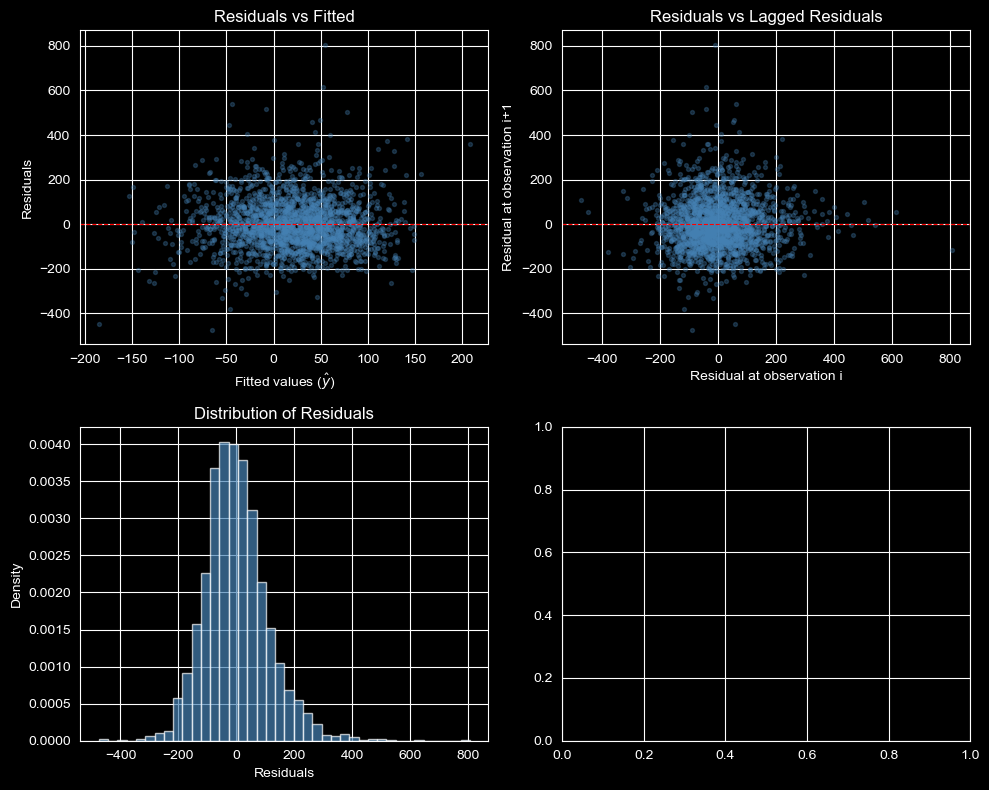

In [70]:
residuals  = model.resid
fitted_vals = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Residuals vs Fitted — checks linearity and homoscedasticity
axes[0, 0].scatter(fitted_vals, residuals, alpha=0.3, s=8, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 0].set_xlabel('Fitted values ($\\hat{y}$)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Residuals vs Lagged Residuals — checks independence
axes[0, 1].scatter(residuals[:-1], residuals[1:], alpha=0.3, s=8, color='steelblue')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 1].set_xlabel('Residual at observation i')
axes[0, 1].set_ylabel('Residual at observation i+1')
axes[0, 1].set_title('Residuals vs Lagged Residuals')

# 3. Histogram of residuals — checks normality
axes[1, 0].hist(residuals, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Distribution of Residuals')



plt.tight_layout()
plt.show()

In [71]:
# Written Answer Here: 

# Evaluate each of the four assumptions based on the plots above:
#
# 1. Linearity — what do you observe in the Residuals vs Fitted plot?
#
# 2. Homoscedasticity — is the variance of residuals constant, or does it change?
#
# 3. Independence — based on the lagged residuals plot and the study design,
#    do you have any concerns about independence?
#
# 4. Normality — what does the histogram tell you?

<div style="background:#cce5ff; border-left:6px solid #004085; padding:12px 18px; border-radius:6px; margin-bottom:8px; color:#004085;">
<h2 style="margin:0;">Final Question: What Does This Analysis Tell Us About HIV Treatment?</h2>
<p style="margin:8px 0 0 0; font-size:14px;">You have now explored this dataset through EDA, hypothesis testing, and a linear regression model.
<br><br>
In a short paragraph, summarize what this analysis tells us about HIV treatment in the 1990s.
Your answer should address:
<ol style="margin:8px 0 0 0; font-size:14px; padding-left:20px;">
<li>Which treatment(s) appear most effective at preserving CD4 count, and how confident are you in that conclusion?</li>
<li>Beyond treatment group, which patient characteristics matter most for outcomes?</li>
<li>What are the limitations of this analysis — what can we <em>not</em> conclude from this data alone?</li>
</ol></p>
</div>

In [72]:
# Written Answer Here: 